<a href="https://colab.research.google.com/github/hxxn05/nvidia/blob/yolo/yolov8_videos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.3/977.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

100%|██████████| 49.7M/49.7M [00:00<00:00, 263MB/s]



0: 736x1280 16 cars, 1 truck, 4233.9ms
Speed: 47.0ms preprocess, 4233.9ms inference, 31.1ms postprocess per image at shape (1, 3, 736, 1280)


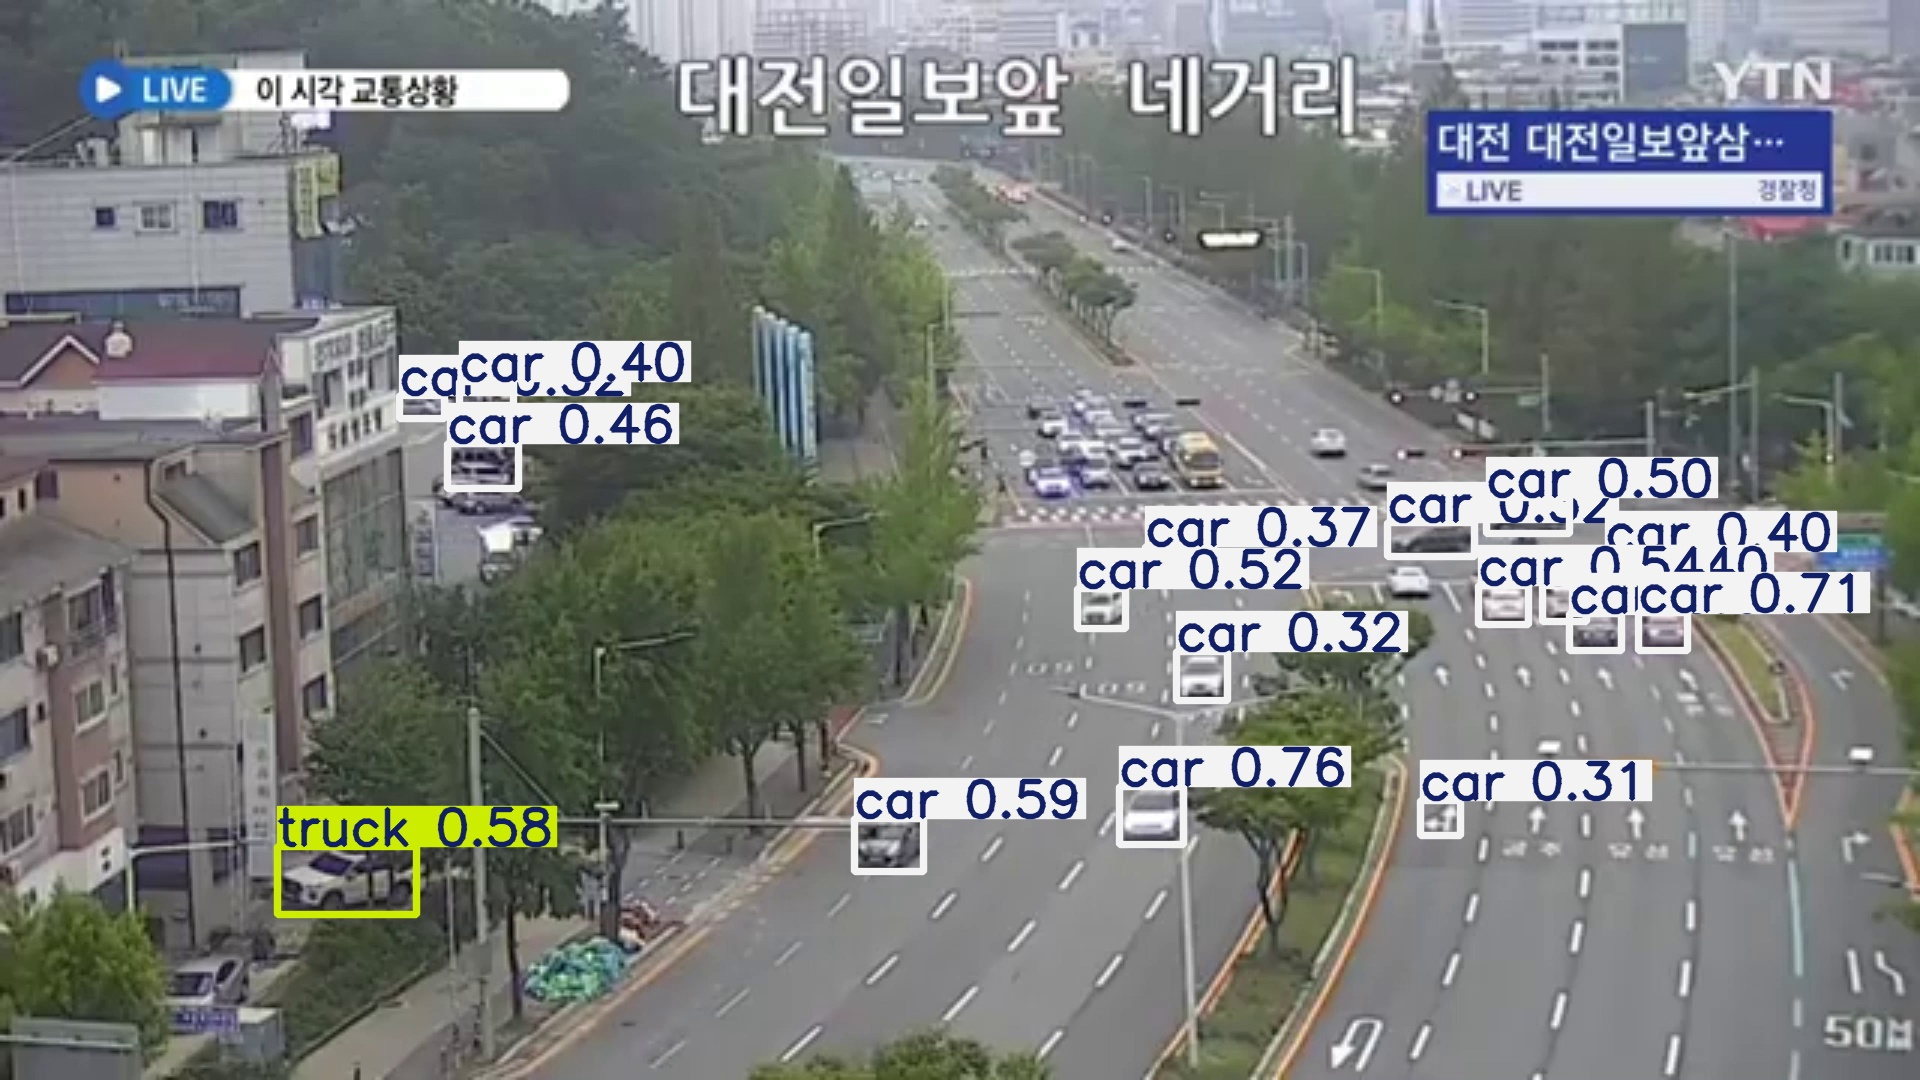


0: 736x1280 13 cars, 1 truck, 3536.0ms
Speed: 31.3ms preprocess, 3536.0ms inference, 2.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 14 cars, 1 truck, 5900.7ms
Speed: 14.8ms preprocess, 5900.7ms inference, 13.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 16 cars, 1 truck, 4274.4ms
Speed: 13.9ms preprocess, 4274.4ms inference, 2.5ms postprocess per image at shape (1, 3, 736, 1280)
동영상 끝 또는 읽기 실패.
탐지 결과 동영상이 '/content/annotated_video.mp4'에 저장되었습니다.


In [1]:
# 1. 필요한 라이브러리 설치
!pip install ultralytics  # YOLOv8 설치
!pip install opencv-python  # OpenCV 설치

# 2. 라이브러리 임포트
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Colab에서 이미지 표시용
from google.colab import drive  # Google Drive 마운트용
from IPython.display import display, Image  # 이미지 표시 추가

# 3. Google Drive 마운트
drive.mount('/content/drive')  # Google Drive를 Colab에 연결

# 4. YOLOv8 모델 로드 (Medium 모델 사용)
model = YOLO('yolov8m.pt')  # 더 강력한 모델 사용 (이전 요청 반영)

# 5. 동영상 파일 물체 탐지 함수
def detect_objects_in_video(video_path):
    # 동영상 파일 읽기
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: '{video_path}' 동영상을 열 수 없습니다.")
        return

    # 동영상 저장 설정 (결과 동영상 저장용)
    output_path = '/content/annotated_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # 코덱 설정
    fps = int(cap.get(cv2.CAP_PROP_FPS))  # 원본 동영상의 FPS
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    max_frames = 100  # 프레임 수 제한 (필요 시 조정, 예: 100프레임만 처리)

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            print("동영상 끝 또는 읽기 실패.")
            break

        # YOLOv8으로 물체 탐지 (신뢰도 임계값 0.3, 이미지 크기 1280)
        results = model(frame, conf=0.3, imgsz=1280)  # conf: 신뢰도 임계값, imgsz: 입력 이미지 크기

        # 탐지 결과 시각화
        annotated_frame = results[0].plot()  # 탐지된 물체 박스와 라벨 표시

        # 결과 프레임 저장
        out.write(annotated_frame)

        # 일부 프레임만 Colab에서 표시 (예: 10프레임마다)
        if frame_count % 10 == 0:
            cv2.imwrite('/content/temp_frame.jpg', annotated_frame)
            display(Image('/content/temp_frame.jpg'))

        frame_count += 1

    # 자원 해제
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"탐지 결과 동영상이 '{output_path}'에 저장되었습니다.")

# 6. 실행 (Google Drive에서 '1.mp4' 자동 가져오기)
video_path = '/content/drive/MyDrive/1.mp4'  # Google Drive 루트에 '1.mp4'가 있다고 가정
detect_objects_in_video(video_path)